# Stochastic Gradient Descent Algorithm: Vanila and Vectorised

In [1]:
from mpl_toolkits import mplot3d
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

In [2]:

# Stochastic Gradient Descent no vectorised...............
def SGD_vanila(X,t, eta=0.001, maxep=100, decay=0.98): # t is the target
    start_time = time.time()
    
    N = len(t)                  # number of data points    
    w = np.zeros((2,1))         # initialise w
    J = np.zeros((maxep))       # the loss in each epoch 
    for ep in range(maxep):     # epochs
        for n in range(N):      # iterations
            w     += (1.0/(  N))*eta*X[n,:].T*(t[n] - w.T* X[n,:].T)
            J[ep] += (1.0/(2*N))*             (t[n] - w.T* X[n,:].T)**2
        eta *= decay
        
    tme = time.time() - start_time
    return w, J, tme

# the above can be vectroised as follows
# Stochastic Gradient Descent vectorised...............
def SGD_vectrzd(X,t, eta=0.001, maxep=100, decay=0.98): # vectorised
    start_time = time.time()
    
    N = len(t)                  # number of data points    
    w = np.zeros((2,1))         # initialise w
    J = np.zeros((maxep))       # the loss in each epoch
    for ep in range(maxep):     # epochs
        w     +=  (1.0/(  N))*eta*X.T*(t - X*w)
        J[ep]  =  (1.0/(2*N))*        (t - X*w).T * (t - X*w) # the loss
        eta   *=  decay
    tme = time.time() - start_time
    return w, J, tme


Add some ploting capabilties

In [3]:
def outSGD(J, w, tme, name='SGD',ax=None, plotJ=True, printw=True):        
    if plotJ:
        ax = ax or plt.gca()
        ax.plot(J[1:],'.b')
    if printw:
        print("y ={}+ {}x1".format(w[0],w[1]), " {} took:    {} seconds ".format(name, tme))


## Generate the Data

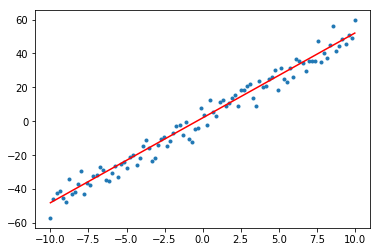

In [4]:
# generate the data
def realFunc(x1):
    return 2 + 5*x1 
    #return 2 + 5*x1**2

N = 100
noise = 5 #40
x1 = np.linspace(-10.0,10.0,N) 
t  = np.random.normal(realFunc(x1),noise) # target

#plot the data along the real model
plt.plot(x1,t,'.')
plt.plot(x1,realFunc(x1),'r')
# generate model solution

# data perperation......................................
x0= np.ones(len(x1))     
X = np.vstack((x0,x1)).T      # add dummy feature
X = np.matrix(X)
t = np.matrix(t).T


y =[0.05612239]+ [3.867632]x1  SGD_vanila took:    0.664017915725708 seconds 
y =[0.0585811]+ [3.88328489]x1  SGD_vectrzd took:    0.00494837760925293 seconds 


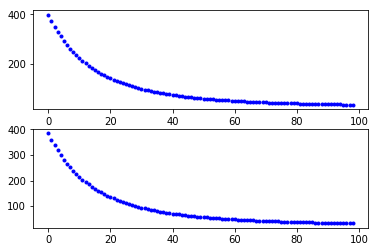

In [5]:
# hyper parameters.......................................
maxep = 100                    # maximum number of epochs
eta   = 0.001                  # learning rate
decay = 0.98                   # decay factor
# ok now compare vanila with vectroised..................
fig, (ax1, ax2) = plt.subplots(2)

w,J, tme = SGD_vanila(X,t, eta, maxep, decay)
outSGD(J, w, tme, 'SGD_vanila', ax1)

w,J, tme = SGD_vectrzd(X,t, eta, maxep, decay)
outSGD(J, w, tme, 'SGD_vectrzd', ax2)

If you play with the learning rate you might encounter instances at which SGD vanila is more resilient to overfitting, while the vectrosied SGD can go quickly into spurious wights when $\eta$ is high. However, the vectorised SGD is far more stable for lower $\eta$ values and much faster for more complex dataset. Note the big difference in how many second each took. Let us see these isues first hand.

### Overfitting due to high learning rate $\eta$ and high number of epochs

y =[1.35224975]+ [5.02893711]x1  SGD_vanila took:    0.5586380958557129 seconds 
y =[-8.68017407e+08]+ [38.55631179]x1  SGD_vectrzd took:    0.0049555301666259766 seconds 


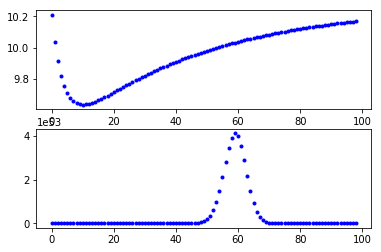

In [6]:
# hyper parameters.......................................
maxep = 100                    # maximum number of epochs
eta   = 0.2                    # learning rate
decay = 0.98                   # decay factor
# ok now compare vanila with vectroised..................
fig, (ax1, ax2) = plt.subplots(2)

w,J, tme = SGD_vanila(X,t, eta, maxep, decay)
outSGD(J, w, tme, 'SGD_vanila', ax1)

w,J, tme = SGD_vectrzd(X,t, eta, maxep, decay)
outSGD(J, w, tme, 'SGD_vectrzd', ax2)

### Underfitting due to low value $\eta$

y =[0.00593297]+ [0.68755783]x1  SGD_vanila took:    0.5523710250854492 seconds 
y =[0.0059716]+ [0.68815417]x1  SGD_vectrzd took:    0.004941701889038086 seconds 


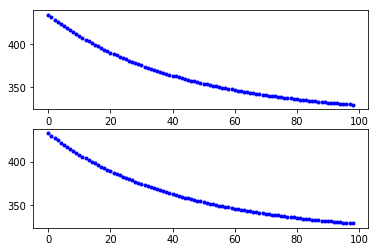

In [7]:
# hyper parameters.......................................
maxep = 100                    # maximum number of epochs
eta   = 0.0001                  # learning rate
decay = 0.98                   # decay factor
# ok now compare vanila with vectroised..................
fig, (ax1, ax2) = plt.subplots(2)

w,J, tme = SGD_vanila(X,t, eta, maxep, decay)
outSGD(J, w, tme, 'SGD_vanila', ax1)

w,J, tme = SGD_vectrzd(X,t, eta, maxep, decay)
outSGD(J, w, tme, 'SGD_vectrzd', ax2)

## Comprehensive Comparison on the learning rate $\eta$

Let us conduct a comprehensive comparison for different learning rates for both to study the effect of the learning rate on both algorithms

In [8]:
# hyper parameters.......................................
maxep = 100                    # maximum number of epochs
#eta   = 0.001                  # learning rate
decay = 0.98                   # decay factor
# ok now compare vanila with vectroised..................


etasL = np.arange(0.01,0.15,0.005)      # low reasonable values
etasH = np.arange(0.16,0.5, 0.005)      # High values that cause SGD vectrosied to go a bit mad :-)
etas  = np.concatenate((etasL , etasH)) # combine both

Jv = np.zeros((len(etas),1))
Jz = np.zeros((len(etas),1))
for i, eta in enumerate(etas):                  # learning rate
    w_v,J_v,_ = SGD_vanila(X,t, eta, maxep, decay)
    w_z,J_z,_ = SGD_vectrzd(X,t, eta, maxep, decay)

    Jv[i] = np.sum(J_v[-10:-1]/10.0)
    Jz[i] = np.sum(J_z[-10:-1]/10.0)
    #print(Jv[i]/len(J_v))



(2,)


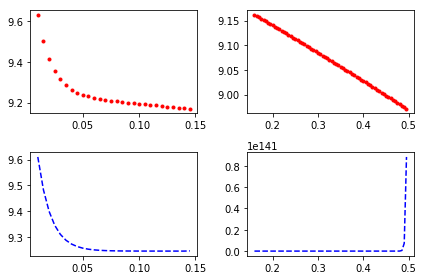

In [9]:

fig, (ax1, ax2) = plt.subplots(2,2)
print(ax1.shape)
ax1[0].plot(etasL,Jv[:len(etasL)], '.r', label='eta')
ax2[0].plot(etasL,Jz[:len(etasL)],'--b',  label='eta')

ax1[1].plot(etasH,Jv[len(etasL):], '.r', label='eta')
ax2[1].plot(etasH,Jz[len(etasL):],'--b', label='eta')


fig.tight_layout()

